In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
plt.style.use('seaborn')
sns.set(font_scale=2)
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.set_random_seed(777)
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_train = pd.read_csv('./data/train.csv')
# df_test = pd.read_csv('./data/test.csv')

In [3]:
df_train.head()

,date&time,WashingMachine,Dryer,temp,icon,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
0,2014-01-01 0:00,0.005686,0.005231,16.67,clear-night,0.53,10.0,Clear,3.95,1022.69,11.23,0.00,1388552400,271.0,0.0,2.41,0.0,3
1,2014-01-01 1:00,0.005635,0.005293,16.19,clear-night,0.52,10.0,Clear,4.18,1022.58,9.92,0.02,1388556000,268.0,0.0,1.68,0.0,3
2,2014-01-01 2:00,0.005570,0.005368,15.69,clear-night,0.55,10.0,Clear,4.41,1023.61,8.72,0.00,1388559600,266.0,0.0,2.59,0.0,3
3,2014-01-01 3:00,0.005543,0.005527,15.29,clear-night,0.58,10.0,Clear,4.29,1024.31,8.25,0.00,1388563200,269.0,0.0,3.29,0.0,3
4,2014-01-01 4:00,0.005597,0.005630,15.37,clear-night,0.60,10.0,Clear,5.12,1024.51,7.38,0.06,1388566800,266.0,0.0,3.95,0.0,3


In [4]:
train_data = [df_train]

icon_mapping = {'clear-day':0, 'clear-night':1, 'cloudy':2, 'fog':3, 'partly-cloudy-day':4, 'partly-cloudy-night':5, 'rain':6, 'snow':7, 'wind':8}
for dataset in train_data:
    dataset['icon'] = dataset['icon'].map(icon_mapping)

In [5]:
train_data = [df_train]

for dataset in train_data:
    dataset['time'] = dataset['date&time'].str.extract('(\d*[:]\d*)', expand=False)

In [6]:
df_train.drop(['date&time', 'visibility', 'summary', 'precipIntensity', 'precipProbability', 'icon', 'apparentTemperature', 'pressure', 'windSpeed', 
              'cloudCover', 'windBearing', 'dewPoint'], axis=1, inplace=True)

In [7]:
time_mapping = {"0:00":0, "1:00":1, "2:00":2, "3:00":3, "4:00":4, "5:00":5, "6:00":6, "7:00":7, "8:00":8, "9:00":9, "10:00":10,
               "11:00":11, "12:00":12, "13:00":13, "14:00":14, "15:00":15, "16:00":16, "17:00":17, "18:00":18, "19:00":19, "20:00":20, "21:00":21, 
               "22:00":22, "23:00":23}
for dataset in train_data:
    dataset['time'] = dataset['time'].map(time_mapping)

In [8]:
df_train.head()

,WashingMachine,Dryer,temp,hum,time,dayOfWeeks
0,0.005686,0.005231,16.67,0.53,0,3
1,0.005635,0.005293,16.19,0.52,1,3
2,0.005570,0.005368,15.69,0.55,2,3
3,0.005543,0.005527,15.29,0.58,3,3
4,0.005597,0.005630,15.37,0.60,4,3


In [9]:
df_all_np = df_train.values.astype(np.float)
scaler = MinMaxScaler()

device = df_all_np[:, 1:2]
norm_device = scaler.fit_transform(device)

temp = df_all_np[:, 2:3]
norm_temp = scaler.fit_transform(temp)

hum = df_all_np[:, 3:4]
norm_hum = scaler.fit_transform(hum)

time = df_all_np[:, 4:5]
norm_time = scaler.fit_transform(time)

day = df_all_np[:, -1:]
norm_day = scaler.fit_transform(day)

x = np.concatenate((norm_time, norm_temp, norm_hum, device, norm_day), axis=1)
print('x.shape ', x.shape)
print('x[0] ', x[0])
print('x[-1]', x[-1])

y = device

x.shape  (17520, 5)
x[0]  [0.         0.29226774 0.48863636 0.00523111 0.5       ]
x[-1] [1.         0.46970571 0.625      0.00315    0.66666667]


In [10]:
input_data_column_cnt = 5
output_data_column_cnt = 1

seq_length = 24
rnn_cell_hidden_dim = 20
forget_bias = 1.0
num_stacked_layers = 1
keep_prob = 1.0

epoch_num = 100
learning_rate = 0.01

In [11]:
dataX = []
dataY = []

for i in range(0, len(y) - seq_length):
    _x = x[i:i+seq_length]
    _y = y[i+seq_length]
    if i is 0:
        print(_x, '->', _y)
    dataX.append(_x)
    dataY.append(_y)

[[0.         0.29226774 0.48863636 0.00523111 0.5       ]
 [0.04347826 0.28765147 0.47727273 0.00529333 0.5       ]
 [0.08695652 0.28284285 0.51136364 0.00536778 0.5       ]
 [0.13043478 0.27899596 0.54545455 0.00552722 0.5       ]
 [0.17391304 0.27976534 0.56818182 0.00563    0.5       ]
 [0.2173913  0.27437969 0.625      0.00578833 0.5       ]
 [0.26086957 0.27043662 0.63636364 0.00581722 0.5       ]
 [0.30434783 0.26457011 0.64772727 0.00572667 0.5       ]
 [0.34782609 0.27139835 0.67045455 0.00602167 0.5       ]
 [0.39130435 0.29592229 0.68181818 0.00580167 0.5       ]
 [0.43478261 0.30784766 0.625      0.00622833 0.5       ]
 [0.47826087 0.32121562 0.53409091 0.00856167 0.5       ]
 [0.52173913 0.33217927 0.5        0.005875   0.5       ]
 [0.56521739 0.33977688 0.47727273 0.00597389 0.5       ]
 [0.60869565 0.33996922 0.46590909 0.00596056 0.5       ]
 [0.65217391 0.34102712 0.47727273 0.00631222 0.5       ]
 [0.69565217 0.33891133 0.48863636 0.00633    0.5       ]
 [0.73913043 0

In [12]:
train_size = int(len(dataY) * 0.7)
test_size = len(dataY) - train_size

trainX = np.array(dataX[0:train_size])
trainY = dataY[0:train_size]

testX = np.array(dataX[train_size:len(dataX)])
testY = dataY[train_size:len(dataY)]

print(np.shape(trainY))

(12247, 1)


In [13]:
X = tf.placeholder(tf.float32, [None, seq_length, input_data_column_cnt], name='X')
print(X)
Y = tf.placeholder(tf.float32, [None, 1], name='Y')
print(Y)

targets = tf.placeholder(tf.float32, [None, 1], name='train_Y')
print(targets)

predictions = tf.placeholder(tf.float32, [None, 1], name='predicted_Y')
print(predictions)

Tensor("X:0", shape=(?, 24, 5), dtype=float32)
Tensor("Y:0", shape=(?, 1), dtype=float32)
Tensor("train_Y:0", shape=(?, 1), dtype=float32)
Tensor("predicted_Y:0", shape=(?, 1), dtype=float32)


In [14]:
def lstm_cell():
    cell = tf.contrib.rnn.BasicLSTMCell(num_units=rnn_cell_hidden_dim, forget_bias=forget_bias, state_is_tuple=True, activation=tf.nn.softsign)
    if keep_prob < 1.0:
        cell = tf.contrib.rnn.DropoutWrapper(cell, output_keep_prob=keep_prob)
    return cell

stackedRNNs = [lstm_cell() for _ in range(num_stacked_layers)]
multi_cells = tf.contrib.rnn.MultiRNNCell(stackedRNNs, state_is_tuple=True) if num_stacked_layers > 1 else lstm_cell()

hypothesis, _states = tf.nn.dynamic_rnn(multi_cells, X, dtype=tf.float32)
print("hypothesis: ", hypothesis)

hypothesis = tf.contrib.layers.fully_connected(hypothesis[:, -1], output_data_column_cnt, activation_fn=tf.identity)

Instructions for updating:
Use the retry module or similar alternatives.
hypothesis:  Tensor("rnn/transpose_1:0", shape=(?, 24, 20), dtype=float32)


In [15]:
loss = tf.reduce_sum(tf.square(hypothesis - Y))
optimizer = tf.train.AdamOptimizer(learning_rate)

train = optimizer.minimize(loss)
rmse = tf.sqrt(tf.reduce_mean(tf.squared_difference(targets, predictions)))

In [16]:
train_error_summary = []
test_error_summary = []
test_predict = ''
predict_array = []

sess = tf.Session()
sess.run(tf.global_variables_initializer())

start_time = datetime.datetime.now()
print('학습 시작')
for epoch in range(epoch_num):
    _, _loss = sess.run([train, loss], feed_dict={X:trainX, Y:trainY})
    
    train_predict = sess.run(hypothesis, feed_dict = {X:trainX})
    train_error = sess.run(rmse, feed_dict = {targets:trainY, predictions:train_predict})
    train_error_summary.append(train_error)

    test_predict = sess.run(hypothesis, feed_dict={X:testX})
    test_error = sess.run(rmse, feed_dict={targets:testY, predictions:test_predict})
    test_error_summary.append(test_error)
        
    if((epoch+1) % 10 == 0) or (epoch == epoch_num - 1):    
        print("epoch: {}, train_error(A): {}, test_error(B): {}, B-A: {}".format(epoch+1, train_error, test_error, test_error-train_error))
        
end_time = datetime.datetime.now()
elapsed_time = end_time - start_time
print('elapsed_time:', elapsed_time)
print('elapsed_time per epoch:', elapsed_time/epoch_num)
predict_array.append(test_predict)

학습 시작
epoch: 10, train_error(A): 0.05430687963962555, test_error(B): 0.2297135591506958, B-A: 0.17540667951107025
epoch: 20, train_error(A): 0.03402363881468773, test_error(B): 0.23969073593616486, B-A: 0.20566709339618683
epoch: 30, train_error(A): 0.019061291590332985, test_error(B): 0.2299385964870453, B-A: 0.21087729930877686
epoch: 40, train_error(A): 0.010801476426422596, test_error(B): 0.23346692323684692, B-A: 0.2226654440164566
epoch: 50, train_error(A): 0.007766227703541517, test_error(B): 0.23190541565418243, B-A: 0.22413918375968933
epoch: 60, train_error(A): 0.007776494137942791, test_error(B): 0.23171700537204742, B-A: 0.22394050657749176
epoch: 70, train_error(A): 0.0078042419627308846, test_error(B): 0.23238220810890198, B-A: 0.22457796335220337
epoch: 80, train_error(A): 0.0074292863719165325, test_error(B): 0.2316560596227646, B-A: 0.22422677278518677
epoch: 90, train_error(A): 0.007287096232175827, test_error(B): 0.23168382048606873, B-A: 0.2243967205286026
epoch: 10

In [17]:
def error_graph(i, train, test):
    plt.figure()
    plt.plot(train[i*100:(i+1)*100], 'r')
    plt.plot(test[i*100:(i+1)*100], 'b')

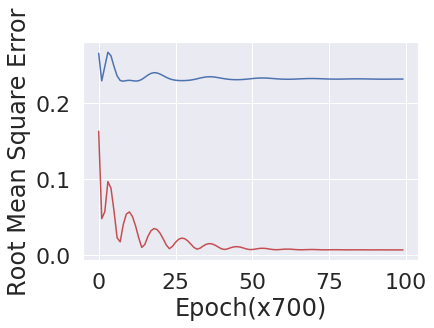

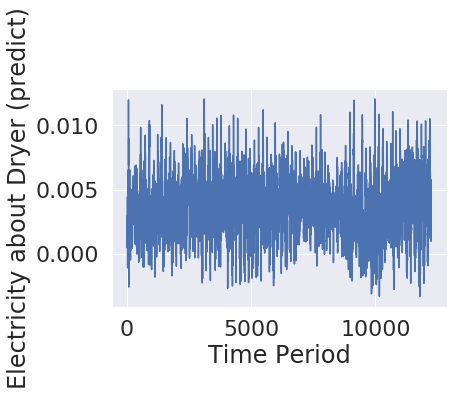

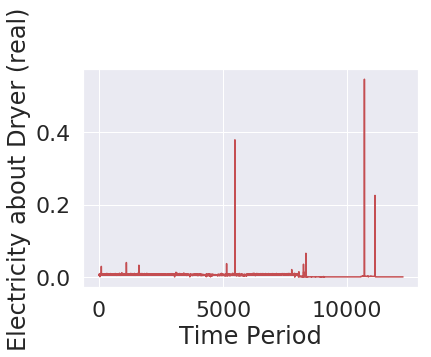

In [18]:
plt.figure(1)
plt.plot(train_error_summary, 'r')
plt.plot(test_error_summary, 'b')
plt.xlabel('Epoch(x700)')
plt.ylabel('Root Mean Square Error')

plt.figure(2)
plt.plot(train_predict, 'b')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (predict)')

plt.figure(3)
plt.plot(trainY, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (real)')
plt.show()

In [19]:
testY[-1]

array([0.00315])

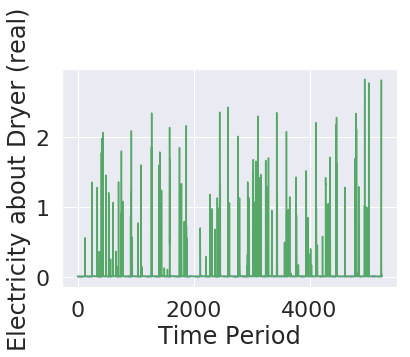

In [20]:
plt.figure()
plt.plot(predict_array[0],'b')
plt.plot(testY, 'g')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (real)')
plt.show()